In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import time

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../archive/data.csv")

In [3]:
df = df.drop(columns=["id", "Unnamed: 32"])

In [4]:
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

In [5]:
X = df.drop(columns=["diagnosis"])

y = df["diagnosis"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [8]:
model = LogisticRegression(
    max_iter=100
)

In [9]:
%%time

model.fit(X_train, y_train)

CPU times: user 6.62 ms, sys: 88 μs, total: 6.71 ms
Wall time: 9.25 ms


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
test_predictions = model.predict(X_test)

In [11]:
print(
    "Accuracy:",
    accuracy_score(y_test, test_predictions)
)

print(
    "Precision:",
    precision_score(y_test, test_predictions)
)

print(
    "Recall:",
    recall_score(y_test, test_predictions)
)

print(
    "F1 Score:",
    f1_score(y_test, test_predictions)
)

Accuracy: 0.9736842105263158
Precision: 0.9761904761904762
Recall: 0.9534883720930233
F1 Score: 0.9647058823529412


In [12]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

print(cm)

[[70  1]
 [ 2 41]]


In [13]:
%%time

model.fit(X_train, y_train)

CPU times: user 4.24 ms, sys: 32 μs, total: 4.27 ms
Wall time: 3.63 ms


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

In [15]:
test_probabilities = model.predict_proba(X_test)[:, 1]

In [16]:
roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.99737962659679


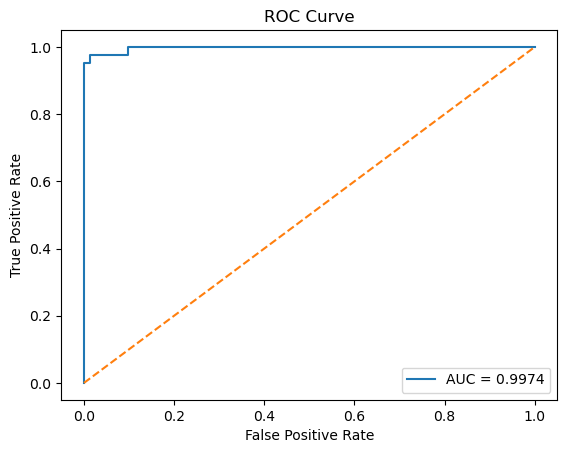

In [17]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    test_probabilities
)

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

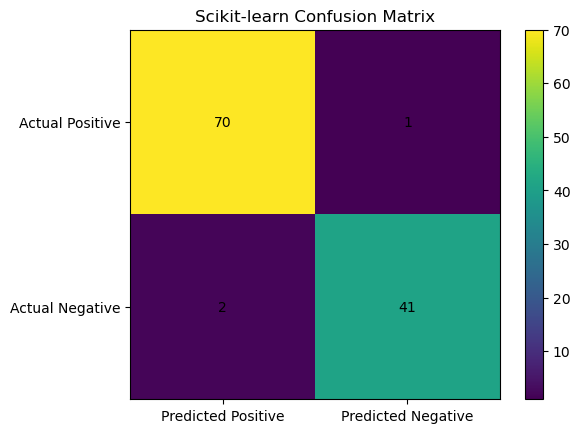

In [18]:
plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0,1],
    ["Predicted Positive", "Predicted Negative"]
)

plt.yticks(
    [0,1],
    ["Actual Positive", "Actual Negative"]
)

plt.title("Scikit-learn Confusion Matrix")

plt.text(0,0, cm[0,0], ha='center', va='center')
plt.text(1,0, cm[0,1], ha='center', va='center')
plt.text(0,1, cm[1,0], ha='center', va='center')
plt.text(1,1, cm[1,1], ha='center', va='center')

plt.show()